In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path, size=12)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

In [12]:
# 데이터 불러오기 및 크기 확인
df = pd.read_csv('data/loan_approval.csv')
df.shape

(2000, 8)

In [13]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [15]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [16]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [22]:
# 범주형 변수 분포
df['loan_approved'].value_counts()

loan_approved
False    1121
True      879
Name: count, dtype: int64

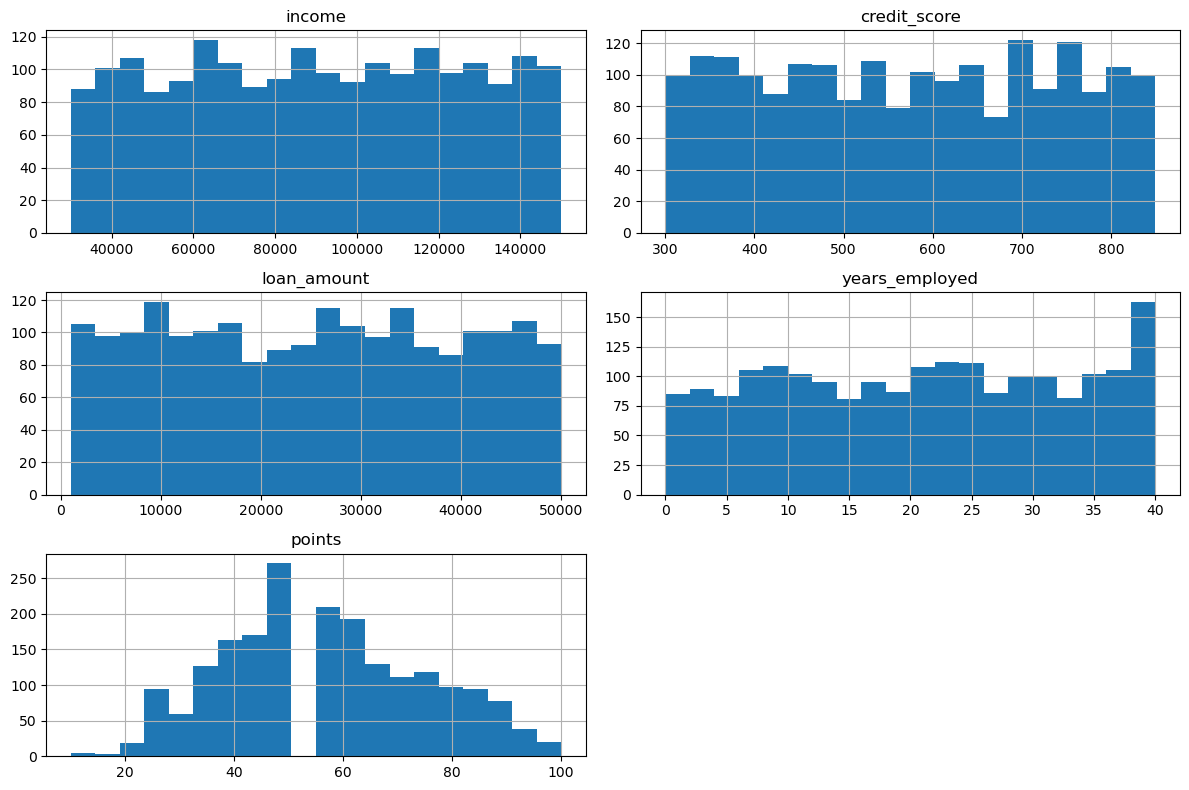

In [25]:
# 수치형 변수 히스토그램
numeric_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


In [28]:
# 타겟 변수 분리
X = df.drop(['loan_approved', 'name', 'city'], axis=1)
y = df['loan_approved']

# 수치형 변수 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 모델 학습
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
# 예측 및 평가
y_pred = dt_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[217   0]
 [  0 183]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       217
        True       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



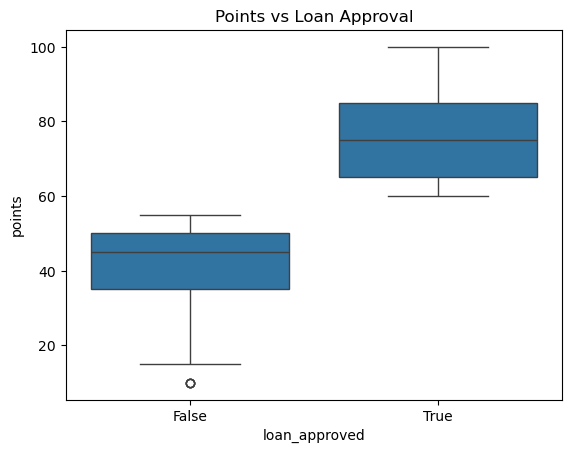

In [30]:
# 상관관계
sns.boxplot(x='loan_approved', y='points', data=df)
plt.title('Points vs Loan Approval')
plt.show()

In [31]:
# 변수 중요도
importances = dt_model.feature_importances_
feature_names = X.columns
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

income: 0.0000
credit_score: 0.0000
loan_amount: 0.0000
years_employed: 0.0000
points: 1.0000


# points는 결정 변수임을 확인
 - 3단계로 이산화 진행하여 재모델링
   - 모델 해석력 향상: 범주형으로 나누면 의사결정 트리에서 분기 기준이 더 명확해짐.
   - 노이즈 완화: 연속형 변수에 있는 작은 흔들림을 무시하고 큰 흐름만 반영할 수 있음.
   - 규칙 기반 분류 가능: “High면 승인, 아니면 거절” 같은 간단한 규칙이 생김.

In [36]:
# points를 3단계로 이산화
import numpy as np

df['points_bin'] = pd.cut(df['points'], bins=[0, 50, 75, 100], labels=[0, 1, 2])

# 재모델링
X = df.drop(['points', 'name', 'city', 'loan_approved'], axis=1)
X['points_bin'] = df['points_bin'].astype(int)

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[208   9]
 [  6 177]]
              precision    recall  f1-score   support

       False       0.97      0.96      0.97       217
        True       0.95      0.97      0.96       183

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



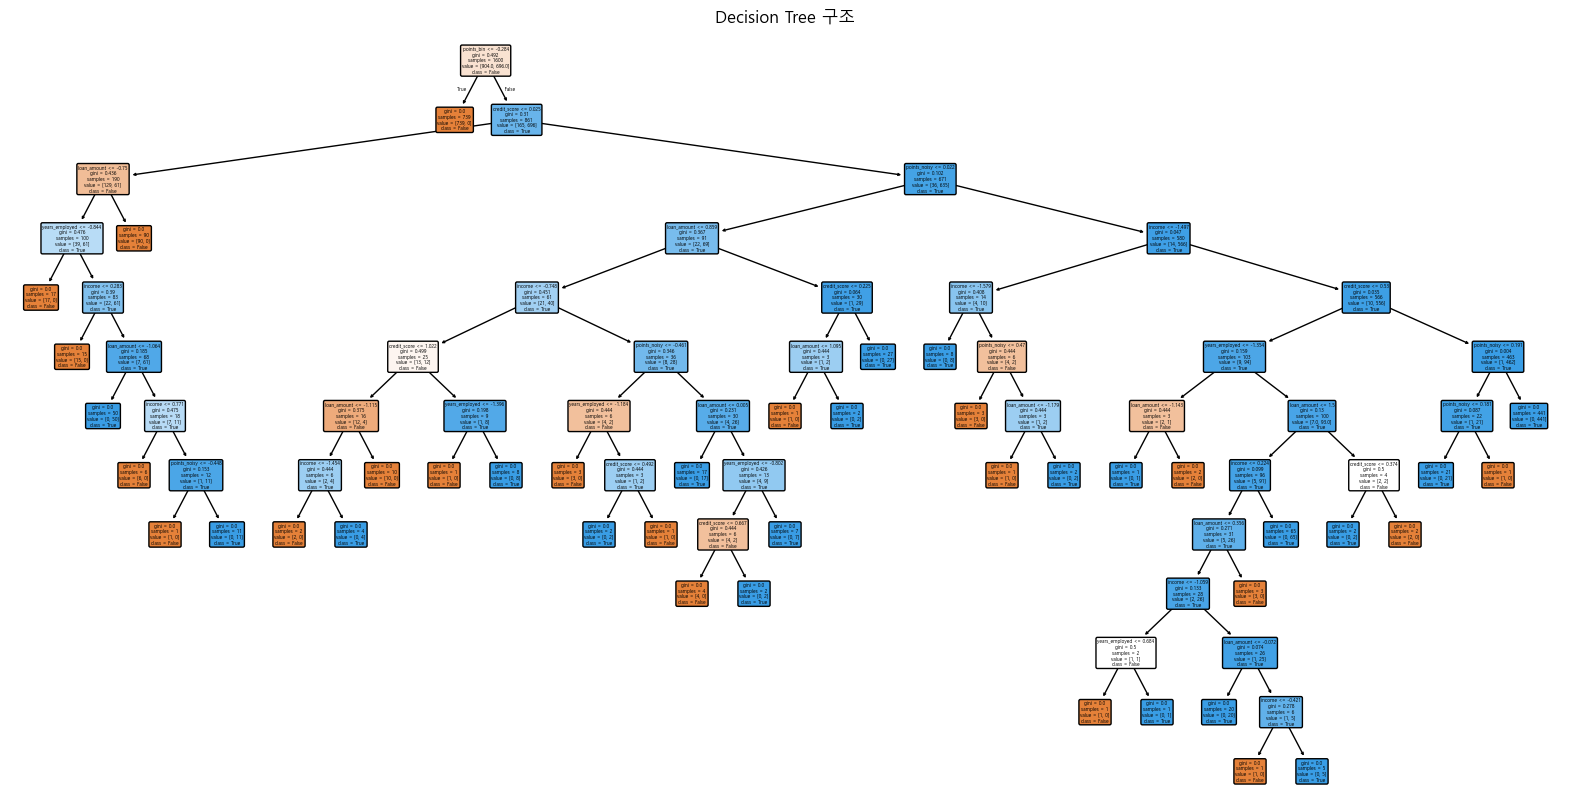

In [40]:
# 의사결정 트리 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['False', 'True'], filled=True, rounded=True)
plt.title("Decision Tree 구조")
plt.show()

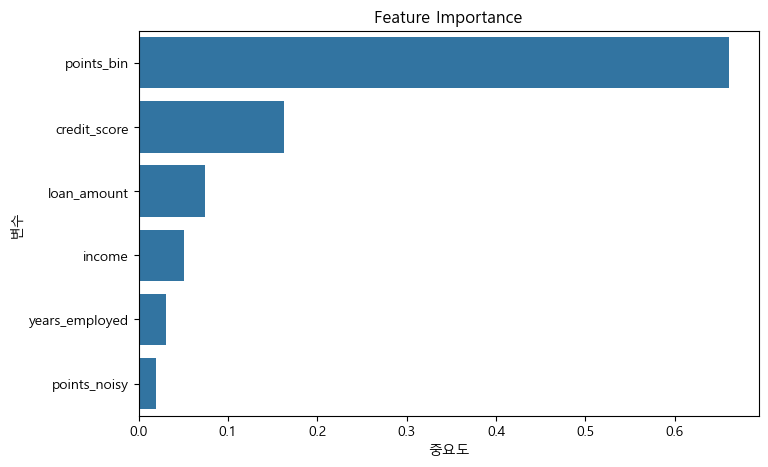

In [41]:
# 변수 중요도 시각화
importances = dt_model.feature_importances_
features = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=features.values, y=features.index)
plt.title("Feature Importance")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.show()

In [42]:
# 분기 규칙 추출 (텍스트 기반)
from sklearn.tree import export_text

tree_rules = export_text(dt_model, feature_names=list(X.columns))
tree_rules

'|--- points_bin <= -0.28\n|   |--- class: False\n|--- points_bin >  -0.28\n|   |--- credit_score <= 0.03\n|   |   |--- loan_amount <= -0.75\n|   |   |   |--- years_employed <= -0.84\n|   |   |   |   |--- class: False\n|   |   |   |--- years_employed >  -0.84\n|   |   |   |   |--- income <= 0.28\n|   |   |   |   |   |--- class: False\n|   |   |   |   |--- income >  0.28\n|   |   |   |   |   |--- loan_amount <= -1.06\n|   |   |   |   |   |   |--- class: True\n|   |   |   |   |   |--- loan_amount >  -1.06\n|   |   |   |   |   |   |--- income <= 0.77\n|   |   |   |   |   |   |   |--- class: False\n|   |   |   |   |   |   |--- income >  0.77\n|   |   |   |   |   |   |   |--- points_noisy <= -0.45\n|   |   |   |   |   |   |   |   |--- class: False\n|   |   |   |   |   |   |   |--- points_noisy >  -0.45\n|   |   |   |   |   |   |   |   |--- class: True\n|   |   |--- loan_amount >  -0.75\n|   |   |   |--- class: False\n|   |--- credit_score >  0.03\n|   |   |--- points_noisy <= 0.02\n|   |   

In [55]:
# 압축 트리 : 깊이 제한 3
compressed_model_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
compressed_model_depth3.fit(X_train, y_train)

y_pred_compressed = compressed_model_depth3.predict(X_test)
print(confusion_matrix(y_test, y_pred_compressed))
print(classification_report(y_test, y_pred_compressed))

[[195  22]
 [  0 183]]
              precision    recall  f1-score   support

       False       1.00      0.90      0.95       217
        True       0.89      1.00      0.94       183

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.95       400



In [54]:
# 압축 트리 : 깊이 제한 2
compressed_model_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)
compressed_model_depth2.fit(X_train, y_train)

y_pred_compressed = compressed_model_depth2.predict(X_test)
print(confusion_matrix(y_test, y_pred_compressed))
print(classification_report(y_test, y_pred_compressed))

[[208   9]
 [ 18 165]]
              precision    recall  f1-score   support

       False       0.92      0.96      0.94       217
        True       0.95      0.90      0.92       183

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



# 성능 변화 요약
1. 기본 트리: 정확도(96%), 해석력(낮음), 과적합 위헙(높음)
2. depth=3:	정확도(94%), 해석력(좋음), 과적합 위헙(낮음)
3. depth=2: 정확도(93%), 해석력(매우 좋음), 과적합 위헙(매우 낮음)

- 트리 깊이가 얕아지면 규칙이 단순해지고 설명 가능성이 높아짐.
- 이런 구조는 비즈니스 로직으로 직접 전환하기도 쉬워짐.

In [ ]:
# 역스케일링으로 평균과 표준편차 추출
means = scaler.mean_
stds = np.sqrt(scaler.var_)

for name, mean, std in zip(X.columns, means, stds):
    print(f"{name}: mean={mean:.2f}, std={std:.2f}")


income: mean=90585.98, std=34479.25
credit_score: mean=573.95, std=160.52
loan_amount: mean=25308.50, std=14203.77
years_employed: mean=20.44, std=11.77
points_noisy: mean=56.66, std=21.20
points_bin: mean=0.71, std=0.73


In [57]:
# 변수 이름 리스트
feature_names = X.columns

# 트리 정보 추출
tree = compressed_model_depth3.tree_

# 노드별 정보 정리
tree_info = pd.DataFrame({
    "node": range(tree.node_count),
    "feature_index": tree.feature,
    "feature_name": [feature_names[i] if i != -2 else "leaf" for i in tree.feature],
    "threshold": tree.threshold,
    "left_child": tree.children_left,
    "right_child": tree.children_right,
    "samples": tree.n_node_samples,
    "impurity": tree.impurity
})

# 분기 노드만 필터링
split_nodes = tree_info[tree_info["feature_index"] != -2]
split_nodes[["node", "feature_name", "threshold"]]

,node,feature_name,threshold
0,0,points_bin,-0.284235
2,2,credit_score,0.025255
3,3,loan_amount,-0.750400
6,6,points_noisy,0.021768


# credit_score <= 0.03
- mean=573.95, std=160.52, z-score=0.03
  - 573.95 + (0.03×160.52) = 573.95 + 4.8156 ≈ 578.76
# income <= -0.75
- mean=90585.98, std=34479.25, z-score=-0.75
  - 90,585.98 + (−0.75×34,479.25) = 90,585.98 − 25,859.44 ≈ 64,726

In [ ]:
def predict_loan_approval(points_bin, credit_score, income):
    # points_bin은 'Low', 'Medium', 'High' 중 하나
    if points_bin == 'Low':
        return False                # 점수가 낮으면 무조건 거절
    elif credit_score <= 578.76:
        return False                # 신용 점수가 낮으면 거절
    elif income <= 64726:
        return False                # 소득이 매우 낮으면 거절
    else:
        return True                 # 나머지는 승인